# Examen Práctico — Primer Parcial
## Tópicos de Big Data

**Instrucciones generales**

- Este notebook es tu entregable. Complétalo en orden, sin borrar los enunciados.
- Al final debes subir este archivo (`.ipynb`) al repositorio de GitHub del curso, en la carpeta correspondiente a tu nombre/usuario.
- Se evaluará tanto el código (que corra sin errores, de arriba hacia abajo) como tus interpretaciones escritas en las celdas de texto marcadas como *"Interpretación"*.
- Cada quien trabaja con **un dataset distinto**, asignado por la profesora. No copies celdas de un compañero con un dataset diferente: aunque las preguntas se parecen, los datos y las columnas no son las mismas.


## 0. Datos del alumno

Completa la siguiente celda con tus datos y el nombre del dataset que te fue asignado.

In [22]:
# --- COMPLETA CON TUS DATOS ---
NOMBRE = "Aarón Martínez Garcidueñas"
MATRICULA = "81424"
DATASET_ASIGNADO = "homicidios" 

print(f"Alumno: {NOMBRE}")
print(f"Matrícula: {MATRICULA}")
print(f"Dataset asignado: {DATASET_ASIGNADO}")


Alumno: Aarón Martínez Garcidueñas
Matrícula: 81424
Dataset asignado: homicidios


## 1. Configuración del entorno virtual (Visual Studio Code)

Antes de instalar librerías directamente en tu sistema, es una buena práctica crear un
**entorno virtual** exclusivo para este examen. Esto evita conflictos de versiones con
otros proyectos y hace que tu entorno de trabajo sea reproducible.

**Requisitos previos en VS Code:** ten instaladas las extensiones oficiales **"Python"**
y **"Jupyter"** (ambas de Microsoft), disponibles en la pestaña de Extensiones (ícono de
cuadritos en la barra lateral izquierda, o `Ctrl+Shift+X` / `Cmd+Shift+X`).

Abre una terminal **dentro de VS Code** (menú **Terminal → New Terminal**, o
`` Ctrl+ñ ``/`` Ctrl+` ``) y verifica que estés ubicado en la carpeta de tu repositorio
del curso (donde vas a guardar este notebook).

### Windows (PowerShell, terminal integrada de VS Code)

```powershell
# 1. Crear el entorno virtual (se creará una carpeta llamada ".venv")
python -m venv .venv

# 2. Activar el entorno virtual
.venv\Scripts\Activate.ps1

# Si PowerShell bloquea la ejecución de scripts, ejecuta una sola vez:
#   Set-ExecutionPolicy -Scope CurrentUser RemoteSigned
# y vuelve a intentar activar el entorno.

# 3. Instalar las librerías necesarias
pip install pandas numpy ipykernel matplotlib requests
```

### macOS / Linux (terminal integrada de VS Code, bash o zsh)

```bash
# 1. Crear el entorno virtual (se creará una carpeta llamada ".venv")
python3 -m venv .venv

# 2. Activar el entorno virtual
source .venv/bin/activate

# 3. Instalar las librerías necesarias
pip install pandas numpy ipykernel matplotlib requests
```

> **Nota:** usamos el nombre `.venv` (con punto) porque VS Code lo detecta automáticamente
> dentro de la carpeta del proyecto. Si usas Anaconda/Miniconda en lugar de `venv`, el
> equivalente es:
> ```bash
> conda create -n examen-bigdata python=3.11 pandas numpy ipykernel matplotlib requests -y
> conda activate examen-bigdata
> ```

### Seleccionar el entorno virtual como kernel en VS Code

A diferencia de Jupyter Notebook/Lab, en VS Code **no necesitas registrar el entorno
manualmente con `ipykernel install`**: basta con tener el paquete `ipykernel` instalado
en el entorno (ya quedó instalado en el paso anterior) y seleccionar ese entorno
directamente como kernel del notebook.

1. Abre este archivo `.ipynb` en VS Code.
2. En la esquina superior derecha del notebook, haz clic en el selector de kernel
   (dice algo como **"Select Kernel"** la primera vez).
3. Elige **"Python Environments..."** y de la lista selecciona el entorno `.venv`
   que acabas de crear (debe aparecer como algo como `.venv (Python 3.x.x)` con la
   ruta de tu proyecto).
4. Si no aparece en la lista, haz clic en **"Select Another Kernel" → "Python
   Environments..."** y usa **"Enter interpreter path..."** para localizar manualmente
   el ejecutable dentro de `.venv/bin/python` (macOS/Linux) o `.venv\Scripts\python.exe`
   (Windows).
5. Verifica que quedó bien seleccionado ejecutando la celda de abajo: debe mostrar una
   ruta que contenga la carpeta `.venv` (o el nombre de tu entorno de conda), y no la
   instalación global de Python.

In [5]:
import sys
print(sys.executable)
# Debe mostrar una ruta dentro de tu carpeta "venv" (o de tu entorno "examen-bigdata" si usas conda).
# Si muestra la ruta de tu instalacion global de Python, regresa al paso anterior
# y selecciona el kernel correcto antes de continuar.


c:\Users\aaron\OneDrive\Documentos\Escuela\5to Semestre\Big Data\big_data_aaron\examen_parcial1_aaronmg\.venv\Scripts\python.exe


## 2. Configuración y carga de datos

La siguiente celda **no se modifica**. Contiene la configuración de los 5 datasets
posibles del examen. A partir de tu variable `DATASET_ASIGNADO` de la celda anterior,
el notebook cargará automáticamente el dataset y los metadatos que te corresponden.

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import requests

# --- NO MODIFICAR: configuración de los 5 datasets del examen ---
DATASETS = {
    "alcohol": {
        "csv": "https://ourworldindata.org/grapher/share-of-adults-who-drank-alcohol-in-last-year.csv?v=1&csvType=full&useColumnShortNames=true",
        "meta": "https://ourworldindata.org/grapher/share-of-adults-who-drank-alcohol-in-last-year.metadata.json?v=1&csvType=full&useColumnShortNames=true",
        "valor_col": "alcohol__consumers_past_12_months__pct__age_standardized__sex_both_sexes",
        "filtro_paises": "code",       # columna a usar para filtrar países reales vs. agregados
        "descripcion": "Porcentaje de adultos (15+) que bebieron alcohol en el ultimo anio",
        "unidad": "%",
    },
    "migracion": {
        "csv": "https://ourworldindata.org/grapher/migrant-populations.csv?v=1&csvType=full&useColumnShortNames=true&metric=immigrants&unit=number",
        "meta": "https://ourworldindata.org/grapher/migrant-populations.metadata.json?v=1&csvType=full&useColumnShortNames=true&metric=immigrants&unit=number",
        "valor_col": "immigrants_all",
        "filtro_paises": "owid_region",
        "descripcion": "Numero total de inmigrantes internacionales residiendo en el pais",
        "unidad": "personas",
    },
    "desnutricion": {
        "csv": "https://ourworldindata.org/grapher/number-undernourished.csv?v=1&csvType=full&useColumnShortNames=true",
        "meta": "https://ourworldindata.org/grapher/number-undernourished.metadata.json?v=1&csvType=full&useColumnShortNames=true",
        "valor_col": "_2_1_1_number_of_undernourished_people__000000000024001__value__006132__millions",
        "filtro_paises": "code",
        "descripcion": "Numero de personas subalimentadas (desnutricion)",
        "unidad": "personas",
    },
    "pib": {
        "csv": "https://ourworldindata.org/grapher/gdp-per-capita-worldbank-constant-usd.csv?v=1&csvType=full&useColumnShortNames=true",
        "meta": "https://ourworldindata.org/grapher/gdp-per-capita-worldbank-constant-usd.metadata.json?v=1&csvType=full&useColumnShortNames=true",
        "valor_col": "ny_gdp_pcap_kd",
        "filtro_paises": "code",
        "descripcion": "PIB per capita (dolares constantes de 2015)",
        "unidad": "USD",
    },
    "homicidios": {
        "csv": "https://ourworldindata.org/grapher/homicides-unodc.csv?v=1&csvType=full&useColumnShortNames=true",
        "meta": "https://ourworldindata.org/grapher/homicides-unodc.metadata.json?v=1&csvType=full&useColumnShortNames=true",
        "valor_col": "value__category_total__sex_total__age_total__unit_of_measurement_counts",
        "filtro_paises": "owid_region",
        "descripcion": "Numero de homicidios intencionales por anio",
        "unidad": "homicidios",
    },
}

assert DATASET_ASIGNADO in DATASETS, (
    "DATASET_ASIGNADO debe ser uno de: " + ", ".join(DATASETS.keys())
)

config = DATASETS[DATASET_ASIGNADO]
print(f"Cargando dataset: {DATASET_ASIGNADO}")
print(f"Descripcion: {config['descripcion']} ({config['unidad']})")


Cargando dataset: homicidios
Descripcion: Numero de homicidios intencionales por anio (homicidios)


In [7]:
# Carga de datos y metadatos desde Our World in Data
df = pd.read_csv(
    config["csv"],
    storage_options={'User-Agent': 'Our World In Data data fetch/1.0'}
)
metadata = requests.get(config["meta"]).json()

# Renombramos la columna de valor a "valor" para trabajar mas comodo durante todo el notebook
df = df.rename(columns={config["valor_col"]: "valor"})


In [8]:
df.head(25)

,entity,code,year,valor,owid_region
0,Afghanistan,AFG,2009,1115.000,Asia
1,Afghanistan,AFG,2010,983.000,Asia
2,Afghanistan,AFG,2011,1231.000,Asia
3,Afghanistan,AFG,2012,1948.000,Asia
4,Afghanistan,AFG,2015,3367.000,Asia
5,Afghanistan,AFG,2016,2318.000,Asia
6,Afghanistan,AFG,2017,2424.000,Asia
7,Afghanistan,AFG,2018,2474.000,Asia
8,Afghanistan,AFG,2019,2712.000,Asia
9,Afghanistan,AFG,2020,2570.000,Asia


## 3. Exploración inicial

Antes de responder las preguntas de análisis, explora el dataset: tipos de datos,
dimensiones, valores nulos y estadísticas descriptivas básicas.

In [9]:
# Forma del dataset (filas, columnas)
df.shape


(4914, 5)

In [10]:
# Tipos de datos e informacion general
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 4914 entries, 0 to 4913
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   entity       4914 non-null   str    
 1   code         4399 non-null   str    
 2   year         4914 non-null   int64  
 3   valor        4914 non-null   float64
 4   owid_region  4220 non-null   str    
dtypes: float64(1), int64(1), str(3)
memory usage: 192.1 KB


In [11]:
# Estadisticas descriptivas de la columna 'valor'
df['valor'].describe()

count      4914.000000
mean       8582.853861
std       37590.820449
min           0.000000
25%          37.000000
50%         256.500000
75%        1171.968475
max      450728.880000
Name: valor, dtype: float64

In [12]:
# Conteo de valores nulos por columna
df.isnull().sum()


entity           0
code           515
year             0
valor            0
owid_region    694
dtype: int64

**Interpretación (2-3 líneas):** ¿qué observas sobre los valores nulos, el rango de
años y el tipo de variable con la que vas a trabajar?

*Por lo observado, tenemos 4,914 registros o índices. El dataset tiene 5 columnas, los valores nulos solo están en las columnas de "code" y de "owid_region", esto porque no solo incluye datos por países, sino también por continente y en ellos se deja nula la región owid_region*

## 4. Preguntas de análisis

A continuación responde las 10 preguntas. 

Cada una tiene una celda de código para su solución y, cuando aplica, 
una celda de texto para tu interpretación. Recuerda que tu
dataset (`DATASET_ASIGNADO`) puede o no tener la columna `owid_region`; revisa el
diccionario `DATASETS` de la celda de configuración para saber qué columna (`code` u
`owid_region`) te toca usar para distinguir países reales de agregados (continentes,
"World", grupos de ingreso, etc.).

### Pregunta 1 — Filtrado de países reales y ranking

Filtra el DataFrame para quedarte solo con países reales (usa la columna indicada en `config['filtro_paises']` de tu dataset). Guarda el resultado en una nueva variable `df_paises`. ¿Cuántos países distintos hay? Muestra los 10 países con mayor valor y los 10 con menor valor.

In [13]:
# Pregunta 1
# Tu codigo aqui
df_paises = df[df["owid_region"].notnull()]
n_paises = df_paises["entity"].nunique()
print(f"Número de países distintos: {n_paises}")

mayorvalor10 = df_paises.sort_values("valor", ascending=False).head(10)
menorvalor10 = df_paises.sort_values("valor", ascending=True).head(10)
print(mayorvalor10)
print(menorvalor10)

Número de países distintos: 200
       entity code  year    valor    owid_region
716    Brazil  BRA  2017  63788.0  South America
3093  Nigeria  NGA  2016  63400.0         Africa
715    Brazil  BRA  2016  61208.0  South America
713    Brazil  BRA  2014  59733.0  South America
714    Brazil  BRA  2015  58184.0  South America
712    Brazil  BRA  2013  56845.0  South America
711    Brazil  BRA  2012  56388.0  South America
717    Brazil  BRA  2018  55980.0  South America
709    Brazil  BRA  2010  52289.0  South America
710    Brazil  BRA  2011  52233.0  South America
        entity code  year  valor    owid_region
4747   Vatican  VAT  2011    0.0         Europe
4750   Vatican  VAT  2014    0.0         Europe
4756   Vatican  VAT  2023    0.0         Europe
4755   Vatican  VAT  2022    0.0         Europe
4752   Vatican  VAT  2019    0.0         Europe
4754   Vatican  VAT  2021    0.0         Europe
4748   Vatican  VAT  2012    0.0         Europe
4751   Vatican  VAT  2015    0.0         Euro

**Interpretación:**

*Ya tenemos el filtro para obtener solo aquellos datos que realmente sean de países, filtramos la columna de owid_region para no traer nulos y podemos observar que hay 200 países, que los países con más homicidios acumulados son Brasil y Nigeria y los que menos son El Vaticano y Anguilla. No sorprende que países con problemas de inseguridad y conflictos bélicos salgan hasta arriba, mientras que microestados con poca población tengan casi ninguno o ningún homicidio registrado*

### Pregunta 2 — Filtro por país y rango de años

Elige dos paises (Mexico y algún otro de tu interés) y filtra `df_paises` para mostrar únicamente su información dentro del rango de años disponible para ambos.

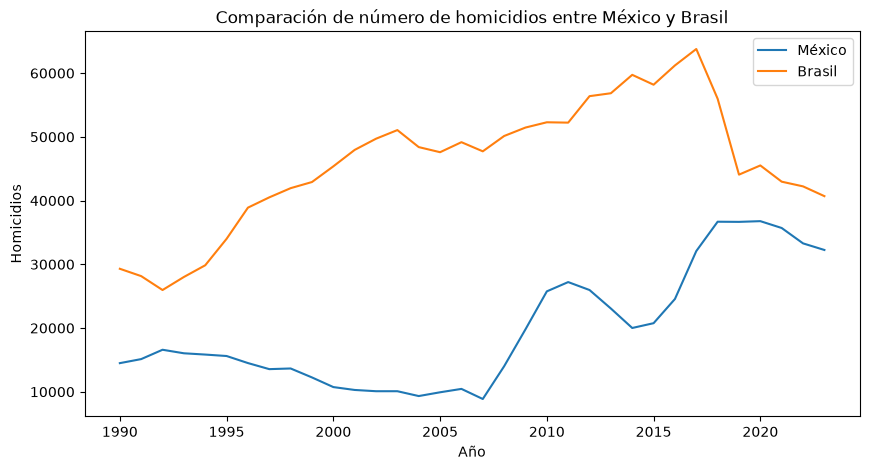

In [14]:
# Pregunta 2
# Tu codigo aqui
mexico = df[df["entity"] == "Mexico"]
brasil = df[df["entity"] == "Brazil"]

anios_mexico = mexico["year"].to_numpy()
tasa_mexico = mexico["valor"].to_numpy()

anios_brasil = brasil["year"].to_numpy()
tasa_brasil = brasil["valor"].to_numpy()

anios_comunes = np.intersect1d(
    anios_mexico,
    anios_brasil
)

anios_mexico = mexico["year"].to_numpy()
tasa_mexico = mexico["valor"].to_numpy()

anios_brasil = brasil["year"].to_numpy()
tasa_brasil = brasil["valor"].to_numpy()

plt.figure(figsize=(10,5))

plt.plot(
    anios_mexico,
    tasa_mexico,
    label="México"
)

plt.plot(
    anios_brasil,
    tasa_brasil,
    label="Brasil"
)

plt.title("Comparación de homicidios")
plt.xlabel("Año")
plt.ylabel("Homicidios")

plt.title('Comparación de número de homicidios entre México y Brasil')
plt.legend()
plt.show()

### Pregunta 3 — Comparación entre países

Elige 5 países de tu interés (de distintos continentes) y compara el valor de tu indicador en el año más reciente disponible. ¿Cuál tiene el valor más alto y cuál el más bajo? Calcula la diferencia entre ambos.

In [15]:
# Pregunta 3
# Tu codigo aqui
usa = df[df["entity"] == "United States"]
japon = df[df["entity"] == "Japan"]
espana = df[df["entity"] == "Spain"]
australia = df[df["entity"] == "Australia"]
sudaf = df[df["entity"] == "South Africa"]

usa_reciente = usa.sort_values(by="year").iloc[-1]
japon_reciente = japon.sort_values(by="year").iloc[-1]
espana_reciente = espana.sort_values(by="year").iloc[-1]
australia_reciente = australia.sort_values(by="year").iloc[-1]
sudaf_reciente = sudaf.sort_values(by="year").iloc[-1]

recientes = pd.DataFrame([
    usa_reciente,
    japon_reciente,
    espana_reciente,
    australia_reciente,
    sudaf_reciente
])

max_row = recientes.loc[recientes["valor"].idxmax()]
min_row = recientes.loc[recientes["valor"].idxmin()]
diferencia = max_row["valor"] - min_row["valor"]

print(recientes[["entity", "year", "valor"]])
print(f"\nPaís más alto: {max_row['entity']} ({max_row['year']}) con {max_row['valor']}")
print(f"País más bajo: {min_row['entity']} ({min_row['year']}) con {min_row['valor']}")
print(f"Diferencia: {diferencia}")

             entity  year    valor
4668  United States  2023  19796.0
2249          Japan  2023    285.0
4222          Spain  2023    331.0
329       Australia  2023    226.0
4078   South Africa  2022  27272.0

País más alto: South Africa (2022) con 27272.0
País más bajo: Australia (2023) con 226.0
Diferencia: 27046.0


**Interpretación:**

*Aquí realizamos un filtrado para obtener el registro más reciente de cada país seleccionado utilizando iloc, trayendo el último registro por índice. En todos los países menos en Sudáfrica, el dato más reciente es de 2023. En Sudáfrica tenemos hasta el 2022. Haciendo la comparación, evidentemente Sudáfrica tiene el mayor número de homicidios, cn 27,272 en ese año. Seguido de Estados Unidos y su mala regulación de armas, con 19,796 El país con menos homicidios es Australia, con 226. Si la comparación fuera en homicidios per cápita, Sudáfrica seguiría liderando la lista.*

### Pregunta 4 — Comparación entre grupos

Define dos grupos de países, el primero "latinoamerica" con Mexico, Colombia y Argentina, y el segundo "Asia" con China, Japon y Vietnam ( si algun pais no tiene informacion disponible, sustitúyelo por algún otro) y calcula el promedio de tu indicador en el año más reciente disponible.

In [16]:
# Pregunta 4
# Tu codigo aqui
latinoamerica = ["Mexico", "Colombia", "Argentina"]
asia = ["China", "Japan", "South Korea"]  # Vietnam sustituido: sus datos terminan en 2011

def valor_mas_reciente(pais):
    datos_pais = df_paises[df_paises["entity"] == pais].sort_values(by="year")
    return datos_pais.iloc[-1]

datos_latam = pd.DataFrame([valor_mas_reciente(p) for p in latinoamerica])
datos_asia = pd.DataFrame([valor_mas_reciente(p) for p in asia])

print("Latinoamérica:")
print(datos_latam[["entity", "year", "valor"]])
promedio_latam = datos_latam["valor"].mean()

print("\nAsia:")
print(datos_asia[["entity", "year", "valor"]])
promedio_asia = datos_asia["valor"].mean()

print(f"\nPromedio Latinoamérica: {promedio_latam:.2f}")
print(f"Promedio Asia: {promedio_asia:.2f}")

Latinoamérica:
         entity  year    valor
2751     Mexico  2023  32252.0
1002   Colombia  2023  13035.0
220   Argentina  2023   2046.0

Asia:
           entity  year   valor
968         China  2020  7157.0
2249        Japan  2023   285.0
4112  South Korea  2023   247.0

Promedio Latinoamérica: 15777.67
Promedio Asia: 2563.00


**Interpretación:**

*Cambié Vietnam por Corea del Sur porque sus datos solo llegaban hasta el 2011 y por la similitud cultural que tiene dicho país con Japón y China. Como era de esperarse, el promedio de homicidios en latinoamérica es notablemente mayor que en asia, siendo 2563.00 en asia y 15777.67 en LATAM. México es el país con mayor número de homicidios dentro de los países comparados de latinoamérica y en el caso de asia es china el que concentra más. En LATAM Argentina es el que menor cantidad de homicidios registró y en Asia s Corea del Sur*

### Pregunta 5 — Tendencia temporal de un país

Para un país de tu elección, analiza cómo cambió tu indicador a lo largo del tiempo disponible en el dataset. ¿En qué año tuvo su valor máximo y en cuál el mínimo? ¿La tendencia general es creciente, decreciente o fluctuante?

Mexico: valor máximo 36773.0 en 2020
Mexico: valor mínimo 8867.0 en 2007


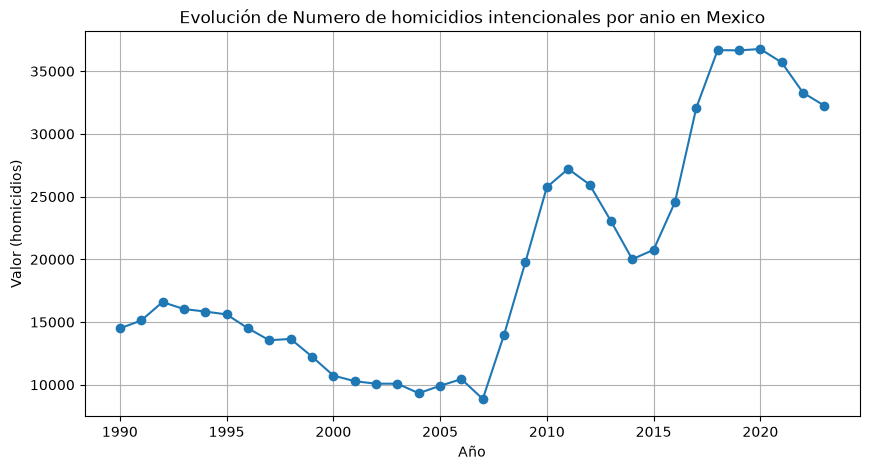

In [17]:
# Pregunta 5
# Tu codigo aqui
pais_q5 = "Mexico"
datos_pais_q5 = df_paises[df_paises["entity"] == pais_q5].sort_values(by="year")

anio_max = datos_pais_q5.loc[datos_pais_q5["valor"].idxmax(), "year"]
valor_max = datos_pais_q5["valor"].max()

anio_min = datos_pais_q5.loc[datos_pais_q5["valor"].idxmin(), "year"]
valor_min = datos_pais_q5["valor"].min()

print(f"{pais_q5}: valor máximo {valor_max} en {anio_max}")
print(f"{pais_q5}: valor mínimo {valor_min} en {anio_min}")

plt.figure(figsize=(10, 5))
plt.plot(datos_pais_q5["year"], datos_pais_q5["valor"], marker="o")
plt.title(f"Evolución de {config['descripcion']} en {pais_q5}")
plt.xlabel("Año")
plt.ylabel(f"Valor ({config['unidad']})")
plt.grid(True)
plt.show()

**Interpretación:**

*Para esta pregunta escogí México porque no hay país más familiar que el nuestro. También se realizó una gráfica para poder observar visualmente la evolución de nuestro valor. El año en que obtuvo su valor máximo fue en el 2020 con 36773.0 y su valor mínimo fue en el 2007 con 8867.0. No sorprende que a partir del 2006 - 2007 vemos una exponencial subida en el valor de homicidios, pues fue el año en el que se declaró la llamada "Guerra contra el Narcotráfico". En 2020 los homicidios alcanzaron su cúspide y en los últimos años parecen tener una ligera baja.*

### Pregunta 6 — Cambio porcentual

Para Mexico, calcula el cambio porcentual entre el primer y el último año con datos disponible. ¿presenta un incremento relativo o una caída? En tus palabras, ¿a qué crees que se debe el resultado? 

In [18]:
# Pregunta 6
# Tu codigo aqui
mexico_q6 = df_paises[df_paises["entity"] == "Mexico"].sort_values(by="year")

primer_registro = mexico_q6.iloc[0]
ultimo_registro = mexico_q6.iloc[-1]

valor_inicial = primer_registro["valor"]
valor_final = ultimo_registro["valor"]

cambio_porcentual = (valor_final - valor_inicial) / valor_inicial * 100

print(f"Primer año con datos: {primer_registro['year']} -> {valor_inicial}")
print(f"Último año con datos: {ultimo_registro['year']} -> {valor_final}")
print(f"Cambio porcentual: {cambio_porcentual:.2f}%")

Primer año con datos: 1990 -> 14493.0
Último año con datos: 2023 -> 32252.0
Cambio porcentual: 122.54%


**Interpretación:**

*El cambio porcentual es de 122.54% desde 1990 hasta 2023. Un incremento muy considerable y lamentable, que como mencioné en la respuesta anterior, viene de años del crecimiento del crimen organizado y el inicio de la llamada guerra contra el narco. Es un cambio porcentual grandísimo.*

### Pregunta 7 — Estadísticas descriptivas con NumPy

Usando NumPy (no `.describe()` de pandas), calcula la media, la mediana y la desviación estándar de tu columna valor entre todos los países reales, para el año más reciente disponible. 
Recuerda filtrar los `NaN` antes de calcular.

In [19]:
# Pregunta 7
# Tu codigo aqui
anio_reciente_q7 = 2023
datos_recientes = df_paises[df_paises["year"] == anio_reciente_q7]

valores = datos_recientes["valor"].to_numpy()
valores = valores[~np.isnan(valores)]

media_np = np.mean(valores)
mediana_np = np.median(valores)
std_np = np.std(valores)

print(f"Año analizado: {anio_reciente_q7}")
print(f"Número de países con dato: {len(valores)}")
print(f"Media (NumPy): {media_np:.2f}")
print(f"Mediana (NumPy): {mediana_np:.2f}")
print(f"Desviación estándar (NumPy): {std_np:.2f}")

Año analizado: 2023
Número de países con dato: 84
Media (NumPy): 2429.75
Mediana (NumPy): 117.00
Desviación estándar (NumPy): 7199.12


**Interpretación:**

*Aquí usamos estadística descriptiva para obtener la media, la mediana y std del último año con registro en todos los países, se escogió 2023 porque solo 10 países tenían datos hasta 2024. El promedio de homicidios alrededor del mundo es de 117 por país, la media es 2429.75 y la std es 7199.12. *

### Pregunta 8 — Visualización de tendencia

Crea una gráfica de líneas con matplotlib que muestre la evolución de tu indicador a lo largo del tiempo para 3 países de tu elección, en una sola figura, con título, etiquetas de ejes y leyenda.

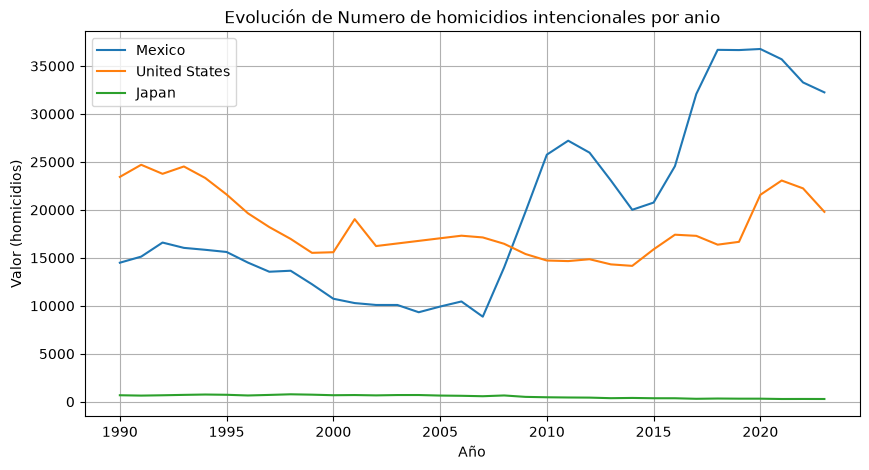

In [25]:
# Pregunta 8
# Tu codigo aqui
paises_q8 = ["Mexico", "United States", "Japan"]

plt.figure(figsize=(10, 5))
for pais in paises_q8:
    datos = df_paises[df_paises["entity"] == pais].sort_values(by="year")
    plt.plot(datos["year"], datos["valor"], label=pais)

plt.title(f"Evolución de {config['descripcion']}")
plt.xlabel("Año")
plt.ylabel(f"Valor ({config['unidad']})")
plt.legend()
plt.grid(True)
plt.show()

**Interpretación:**

*La gráfia permite ver el aumento notable de los homicidios en México a partir del 2008 aprox, superando incluso a Estados Unidos, el cual también ha tenido un repunte en los últimos años, en 2021 principalmente. Por otro lado, japón se ha mantenido casi constante en su número de homicidios, mostrando incluso un ligero declive en los últimos años.*

### Pregunta 9 — Visualización integradora

Crea dos gráficas de barras (horizontales o verticales) con el Top 10 de países según tu indicador en la primera consulta el año de tu nacimiento, y en la segunda el año 2023, ordenados de mayor a menor.  Qué movimientos hubo en ambas gráficas?
Agrega título y etiquetas de ejes.

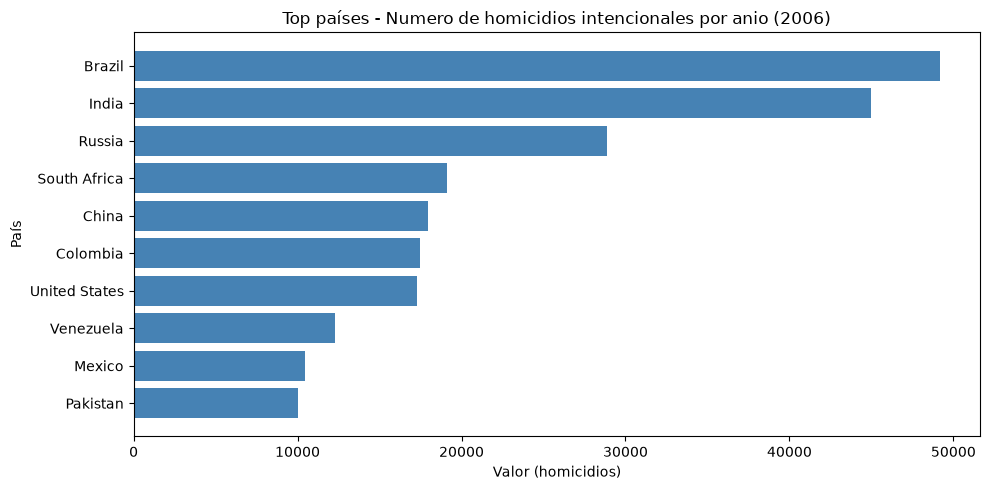

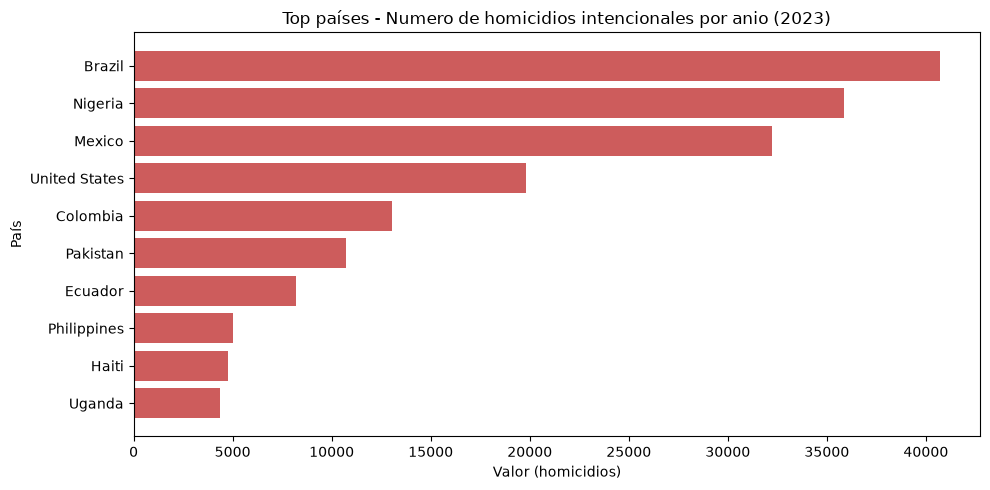

Top 10 en 2006: ['Brazil', 'India', 'Russia', 'South Africa', 'China', 'Colombia', 'United States', 'Venezuela', 'Mexico', 'Pakistan']
Top 10 en 2023: ['Brazil', 'Nigeria', 'Mexico', 'United States', 'Colombia', 'Pakistan', 'Ecuador', 'Philippines', 'Haiti', 'Uganda']


In [24]:
# Pregunta 9
# Tu codigo aqui
anio_nacimiento = 2006
anio_2023 = 2023

top_nacimiento = (
    df_paises[df_paises['year'] == anio_nacimiento]
    .sort_values('valor', ascending=False)
    .head(10)
)

top_2023 = (
    df_paises[df_paises['year'] == anio_2023]
    .sort_values('valor', ascending=False)
    .head(10)
)

# Grafica 1: top 10 en el año de nacimiento
plt.figure(figsize=(10, 5))
plt.barh(top_nacimiento['entity'], top_nacimiento['valor'], color='steelblue')
plt.xlabel(f"Valor ({config['unidad']})")
plt.ylabel("País")
plt.title(f"Top países - {config['descripcion']} ({anio_nacimiento})")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# Grafica 2: top 10 en 2023
plt.figure(figsize=(10, 5))
plt.barh(top_2023['entity'], top_2023['valor'], color='indianred')
plt.xlabel(f"Valor ({config['unidad']})")
plt.ylabel("País")
plt.title(f"Top países - {config['descripcion']} ({anio_2023})")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print(f"Top 10 en {anio_nacimiento}:", list(top_nacimiento['entity']))
print(f"Top 10 en {anio_2023}:", list(top_2023['entity']))

**Interpretación:**

*Del 2006, el año en que nací, hasta acá, Brasil sigue siendo el número 1 de la lista. Estados Unidos aumentó su posición en la tabla, México también subió notablemente. Por otro lado, la India, Rusia y China desaparecieron de los primeros lugares en la lista.*

## 5. Conclusión general

En 5 - 10 líneas, resume qué aprendiste sobre el dataset que te tocó trabajar: ¿qué
patrones encontraste?, ¿qué limitaciones tiene la información (por ejemplo, valores
absolutos sin normalizar por población, datos faltantes, etc.)?, ¿qué harías distinto si
tuvieras más tiempo?

En mi caso, dentro del dataset de homicidios, observamos que en países de
regiones o culturas similares la cantidad de homicidios suele ser más o menos similar, y que factores como el crimen organizado o la regulación de armas (como en México o Estados Unidos) se reflejan claramente en la tendencia lo largo de los años. Algunas limitaciones son que no todos los países comienzan ni terminan en los mismos años, por lo que no puedes hacer una verdadera comparativa global sin perder datos. Además, al ser cifras absolutas, un país con mucha población (como Brasil o Estados Unidos) siempre va a aparecer arriba en los rankings aunque su tasa relativa de homicidios no sea la más alta, lo cual sesga las comparaciones entre países de tamaños muy distintos. Si tuviera más tiempo, normalizaría el indicador por cada 100,000 habitantes cruzando estos datos con población, para poder comparar de form a justa países grandes y pequeños, y también profundizaría en las causas detrás de los picos y caídas más marcados (como el de México en 2020) en lugar de solo describir la tendencia.

## 6. Entrega

1. Verifica que el notebook corra completo de arriba hacia abajo sin errores (`Kernel > Restart & Run All`).
2. Guarda el archivo con el nombre: `apellido_nombre_examen_parcial1.ipynb`.
3. Súbelo al repositorio de GitHub del curso, en una carpeta para este examen.
4. Comparte el link de tu repo y envia una copia del notebook por teams.
